
# GVH Diagonal Cubic 0.2.10 — Action and Variational Principle
## Action candidate, principe variationnel, degrés de liberté et diagnostics de ghosts

**Auteur : Charlemagne O Laurince**

---

## Objectif

Les notebooks 0.2.1 à 0.2.9 ont étudié une famille de métriques diagonales cubiques à partir de leurs conséquences :

\[
g_{\mu\nu}
\rightarrow
\Gamma^\rho_{\mu\nu}
\rightarrow
R^\rho{}_{\sigma\mu\nu}
\rightarrow
G_{\mu\nu}
\rightarrow
T_{\mu\nu}^{\mathrm{eff}}
\rightarrow
\text{stabilité effective}.
\]

Cette version cherche maintenant la direction inverse :

\[
S_{\mathrm{GVH}}
\rightarrow
\delta S_{\mathrm{GVH}}=0
\rightarrow
\text{équations de champ}
\rightarrow
g_{\mu\nu}.
\]

La question centrale est :

> Peut-on construire une action covariante dont la métrique diagonale GVH soit une solution, tout en retrouvant la relativité générale dans une limite contrôlée ?

---

## Statut scientifique

Aucune action GVH fondamentale n'est actuellement dérivée.

Ce notebook construit un **cadre de sélection et de falsification** pour des actions candidates. Il sépare :

1. l'action d'Einstein–Hilbert établie ;
2. des extensions covariantes connues servant de bancs d'essai ;
3. les hypothèses propres à GVH, encore à dériver.

Une métrique choisie puis reconstruite par une source effective ne détermine pas de manière unique son action fondamentale.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

print("SymPy :", sp.__version__)


SymPy : 1.14.0



# 1. Action d'Einstein–Hilbert de référence

L'action gravitationnelle standard est :

\[
S_{\mathrm{EH}}
=
\frac{c^4}{16\pi G}
\int d^4x\sqrt{-g}\,(R-2\Lambda)
+
S_{\mathrm{matière}}.
\]

Sa variation par rapport à \(g^{\mu\nu}\) donne :

\[
G_{\mu\nu}
+
\Lambda g_{\mu\nu}
=
\frac{8\pi G}{c^4}T_{\mu\nu}.
\]

Cette action possède :

- covariance générale ;
- équations métriques du second ordre ;
- deux polarisations tensorielles propagatives dans le vide ;
- limite newtonienne correcte.


In [2]:

G_N, c, Lambda = sp.symbols(
    "G_N c Lambda",
    positive=True,
    finite=True
)

kappa = 8*sp.pi*G_N/c**4
prefactor_EH = c**4/(16*sp.pi*G_N)

print("kappa =")
display(kappa)

print("Préfacteur Einstein-Hilbert =")
display(prefactor_EH)


kappa =


8⋅π⋅G_N
───────
   4   
  c    

Préfacteur Einstein-Hilbert =


    4   
   c    
────────
16⋅π⋅G_N


# 2. Équations d'Euler–Lagrange

Pour des coordonnées généralisées \(q_i(t)\) et un lagrangien \(L\) :

\[
\frac{d}{dt}
\left(
\frac{\partial L}{\partial \dot q_i}
\right)
-
\frac{\partial L}{\partial q_i}
=
0.
\]

Nous construisons une fonction symbolique réutilisable.


In [3]:

def euler_lagrange_equation(L, q, time):
    qdot = sp.diff(q, time)

    return sp.simplify(
        sp.diff(sp.diff(L, qdot), time)
        - sp.diff(L, q)
    )


t = sp.symbols("t", real=True)
q = sp.Function("q")(t)
m, omega = sp.symbols("m omega", positive=True)

L_osc = (
    sp.Rational(1, 2)*m*sp.diff(q, t)**2
    - sp.Rational(1, 2)*m*omega**2*q**2
)

EL_osc = euler_lagrange_equation(L_osc, q, t)

print("Équation variationnelle de l'oscillateur :")
display(sp.factor(EL_osc))


Équation variationnelle de l'oscillateur :


  ⎛           2       ⎞
  ⎜ 2        d        ⎟
m⋅⎜ω ⋅q(t) + ───(q(t))⎟
  ⎜            2      ⎟
  ⎝          dt       ⎠


# 3. Diagnostic hessien et signe cinétique

Pour un système mécanique réduit, la matrice hessienne cinétique est :

\[
K_{ij}
=
\frac{\partial^2L}
{\partial\dot q_i\partial\dot q_j}.
\]

Un diagnostic préliminaire d'absence de ghost exige que les degrés de liberté physiques possèdent une matrice cinétique de signe approprié après élimination des contraintes.

Attention : une valeur propre nulle peut représenter une contrainte ou une symétrie de jauge, pas nécessairement une instabilité.


In [4]:

def kinetic_hessian(L, generalized_coordinates, time):
    velocities = [
        sp.diff(qi, time)
        for qi in generalized_coordinates
    ]

    return sp.Matrix([
        [
            sp.diff(
                sp.diff(L, vi),
                vj
            )
            for vj in velocities
        ]
        for vi in velocities
    ])


q1 = sp.Function("q1")(t)
q2 = sp.Function("q2")(t)

k1, k2, mu = sp.symbols(
    "k1 k2 mu",
    real=True
)

L_two = (
    sp.Rational(1, 2)*k1*sp.diff(q1,t)**2
    + mu*sp.diff(q1,t)*sp.diff(q2,t)
    + sp.Rational(1, 2)*k2*sp.diff(q2,t)**2
)

K_two = kinetic_hessian(
    L_two,
    [q1, q2],
    t
)

print("Matrice cinétique :")
display(K_two)

print("Valeurs propres :")
display(K_two.eigenvals())


Matrice cinétique :


⎡k₁  μ ⎤
⎢      ⎥
⎣μ   k₂⎦

Valeurs propres :


⎧             ____________________________                  __________________ ↪
⎪            ╱   2               2      2                  ╱   2               ↪
⎨k₁   k₂   ╲╱  k₁  - 2⋅k₁⋅k₂ + k₂  + 4⋅μ       k₁   k₂   ╲╱  k₁  - 2⋅k₁⋅k₂ + k ↪
⎪── + ── - ───────────────────────────────: 1, ── + ── + ───────────────────── ↪
⎩2    2                   2                    2    2                   2      ↪

↪ __________   ⎫
↪  2      2    ⎪
↪ ₂  + 4⋅μ     ⎬
↪ ──────────: 1⎪
↪              ⎭


# 4. Pourquoi les dérivées supérieures sont dangereuses

Un lagrangien non dégénéré dépendant de \(\ddot q\), par exemple :

\[
L
=
\frac12\dot q^2
-
\frac{\Omega^2}{2}q^2
+
\frac{\alpha}{2}\ddot q^2,
\]

produit généralement une équation du quatrième ordre.

Cela peut introduire un degré de liberté supplémentaire associé à une instabilité d'Ostrogradski.

Des théories particulières peuvent éviter ce problème par dégénérescence ou contrainte, mais cela doit être démontré.


In [5]:

alpha, Omega = sp.symbols(
    "alpha Omega",
    real=True
)

q_hd = sp.Function("q_hd")(t)

L_hd = (
    sp.Rational(1, 2)*sp.diff(q_hd,t)**2
    - sp.Rational(1, 2)*Omega**2*q_hd**2
    + sp.Rational(1, 2)*alpha*sp.diff(q_hd,t,2)**2
)

EL_hd = sp.simplify(
    sp.diff(L_hd, q_hd)
    - sp.diff(
        sp.diff(L_hd, sp.diff(q_hd,t)),
        t
    )
    + sp.diff(
        sp.diff(L_hd, sp.diff(q_hd,t,2)),
        t,
        2
    )
)

print("Équation avec dérivée supérieure :")
display(sp.factor(EL_hd))


Équation avec dérivée supérieure :


                  4              2          
   2             d              d           
- Ω ⋅q_hd(t) + α⋅───(q_hd(t)) - ───(q_hd(t))
                   4              2         
                 dt             dt          


# 5. Familles d'actions candidates

Une action GVH covariante pourrait appartenir à plusieurs familles.

## A — Einstein–Hilbert uniquement

\[
S
=
\int\sqrt{-g}\,
\frac{M_{\mathrm{Pl}}^2}{2}R.
\]

Elle redonne la relativité générale. Aucun contenu GVH nouveau n'apparaît sans structure supplémentaire.

## B — Scalaire–tenseur minimal

\[
S
=
\int\sqrt{-g}
\left[
\frac{M_{\mathrm{Pl}}^2}{2}F(\varphi)R
-\frac12Z(\varphi)(\nabla\varphi)^2
-V(\varphi)
\right].
\]

## C — Corrections quadratiques de courbure

\[
S
=
\int\sqrt{-g}
\left[
\frac{M_{\mathrm{Pl}}^2}{2}R
+\alpha R^2
+\beta R_{\mu\nu}R^{\mu\nu}
\right].
\]

Le terme \(R^2\) peut être reformulé avec un scalaire supplémentaire. Un terme générique \(R_{\mu\nu}R^{\mu\nu}\) exige une analyse rigoureuse des modes.

## D — Action effective GVH

\[
S_{\mathrm{GVH}}
=
S_{\mathrm{EH}}
+
\epsilon S_{\mathrm{corr}},
\]

avec :

\[
\epsilon\rightarrow0
\quad\Longrightarrow\quad
S_{\mathrm{GVH}}\rightarrow S_{\mathrm{EH}}.
\]


In [6]:

candidate_families = pd.DataFrame([
    {
        "famille": "Einstein-Hilbert",
        "nouveau_DOF": "aucun",
        "ordre_attendu": 2,
        "statut_GVH": "référence"
    },
    {
        "famille": "Scalaire-tenseur minimal",
        "nouveau_DOF": "scalaire",
        "ordre_attendu": 2,
        "statut_GVH": "candidat prudent"
    },
    {
        "famille": "f(R)",
        "nouveau_DOF": "scalaire effectif",
        "ordre_attendu": "4 métrique / 2 reformulé",
        "statut_GVH": "à tester"
    },
    {
        "famille": "Ricci² générique",
        "nouveau_DOF": "modes supplémentaires",
        "ordre_attendu": 4,
        "statut_GVH": "risque élevé"
    },
    {
        "famille": "Terme directionnel non covariant",
        "nouveau_DOF": "indéterminé",
        "ordre_attendu": "indéterminé",
        "statut_GVH": "rejet sans covariantisation"
    }
])

candidate_families


,famille,nouveau_DOF,ordre_attendu,statut_GVH
0,Einstein-Hilbert,aucun,2,référence
1,Scalaire-tenseur minimal,scalaire,2,candidat prudent
2,f(R),scalaire effectif,4 métrique / 2 reformulé,à tester
3,Ricci² générique,modes supplémentaires,4,risque élevé
4,Terme directionnel non covariant,indéterminé,indéterminé,rejet sans covariantisation



# 6. Candidat prudent : action scalaire–tenseur

Pour conserver la covariance tout en permettant une structure additionnelle :

\[
S_{\mathrm{trial}}
=
\int d^4x\sqrt{-g}
\left[
\frac{M_{\mathrm{Pl}}^2}{2}F(\varphi)R
-\frac12Z(\varphi)
g^{\mu\nu}\partial_\mu\varphi\partial_\nu\varphi
-V(\varphi)
\right]
+
S_m.
\]

Conditions minimales :

\[
F(\varphi)>0
\]

pour conserver un couplage gravitationnel effectif positif, et

\[
Z_{\mathrm{eff}}(\varphi)>0
\]

pour un signe cinétique scalaire sain dans la représentation appropriée.

Le champ \(\varphi\) n'est pas automatiquement le « temps directionnel » GVH. Cette identification devra être dérivée.


In [7]:

Mpl, phi0 = sp.symbols(
    "Mpl phi0",
    positive=True
)

xi, zeta, lam = sp.symbols(
    "xi zeta lam",
    real=True
)

phi = sp.symbols("phi", real=True)

F_phi = 1 + xi*phi**2/Mpl**2
Z_phi = 1 + zeta*phi**2/Mpl**2
V_phi = lam*phi**4/4

trial_functions = pd.DataFrame([{
    "F(phi)": str(F_phi),
    "Z(phi)": str(Z_phi),
    "V(phi)": str(V_phi),
    "Einstein_limit": "xi=zeta=lam=0"
}])

trial_functions


,F(phi),Z(phi),V(phi),Einstein_limit
0,1 + phi**2*xi/Mpl**2,1 + phi**2*zeta/Mpl**2,lam*phi**4/4,xi=zeta=lam=0



# 7. Limite d'Einstein

La limite de référence doit être explicite :

\[
F(\varphi)\rightarrow1,
\qquad
Z(\varphi)(\nabla\varphi)^2\rightarrow0,
\qquad
V(\varphi)\rightarrow0.
\]

Alors :

\[
S_{\mathrm{trial}}
\rightarrow
S_{\mathrm{EH}}.
\]


In [8]:

einstein_limit = {
    "F_limit": sp.simplify(
        F_phi.subs({
            xi: 0,
            zeta: 0,
            lam: 0
        })
    ),
    "Z_limit": sp.simplify(
        Z_phi.subs({
            xi: 0,
            zeta: 0,
            lam: 0
        })
    ),
    "V_limit": sp.simplify(
        V_phi.subs({
            xi: 0,
            zeta: 0,
            lam: 0
        })
    )
}

einstein_limit


{'F_limit': 1, 'Z_limit': 1, 'V_limit': 0}


# 8. Modèle réduit homogène

Pour tester le principe variationnel, on utilise une métrique FLRW plate :

\[
ds^2
=
-N(t)^2dt^2
+
a(t)^2d\mathbf x^2.
\]

Le lapse \(N(t)\) joue le rôle de multiplicateur de Lagrange et produit une contrainte hamiltonienne.

Pour un champ homogène \(\varphi(t)\), un lagrangien réduit de référence est :

\[
L
=
-\frac{3M_{\mathrm{Pl}}^2a\dot a^2}{N}
+
a^3
\left(
\frac{\dot\varphi^2}{2N}
-
NV(\varphi)
\right).
\]

Ce modèle n'est pas la métrique statique GVH ; il sert à vérifier la structure variationnelle et les contraintes.


In [9]:

a = sp.Function("a")(t)
N = sp.Function("N")(t)
varphi = sp.Function("varphi")(t)

V = sp.Function("V")

L_mini = (
    -3*Mpl**2*a*sp.diff(a,t)**2/N
    + a**3*sp.diff(varphi,t)**2/(2*N)
    - N*a**3*V(varphi)
)

EL_a = euler_lagrange_equation(
    L_mini,
    a,
    t
)

EL_phi = euler_lagrange_equation(
    L_mini,
    varphi,
    t
)

constraint_N = sp.simplify(
    sp.diff(L_mini, N)
)

print("Équation pour a(t) :")
display(sp.factor(EL_a))

print("Équation pour varphi(t) :")
display(sp.factor(EL_phi))

print("Contrainte issue de N(t) :")
display(sp.factor(constraint_N))


Équation pour a(t) :


  ⎛                    2                                2                      ↪
  ⎜       2           d                2      ⎛d       ⎞         2      d      ↪
3⋅⎜- 4⋅Mpl ⋅N(t)⋅a(t)⋅───(a(t)) - 2⋅Mpl ⋅N(t)⋅⎜──(a(t))⎟  + 4⋅Mpl ⋅a(t)⋅──(N(t ↪
  ⎜                     2                     ⎝dt      ⎠                dt     ↪
  ⎝                   dt                                                       ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                          2    ↪
                                                                       2⋅N (t) ↪

↪                                                                      2⎞
↪    d             3                  2            2    ⎛d            ⎞ ⎟
↪ ))⋅──(a(t)) + 2⋅N (t)⋅V(varphi(t))⋅a (t) - N(t)⋅a (t)⋅⎜──(varphi(t))⎟ ⎟
↪    dt                                                 ⎝dt           ⎠ ⎟
↪                                                      

Équation pour varphi(t) :


 ⎛                                                   2                         ↪
 ⎜   3             d                                d                       d  ↪
-⎜- N (t)⋅a(t)⋅──────────(V(varphi(t))) - N(t)⋅a(t)⋅───(varphi(t)) - 3⋅N(t)⋅── ↪
 ⎜             dvarphi(t)                             2                     dt ↪
 ⎝                                                  dt                         ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                  2            ↪
                                                                 N (t)         ↪

↪                                                   ⎞       
↪        d                    d        d            ⎟  2    
↪ (a(t))⋅──(varphi(t)) + a(t)⋅──(N(t))⋅──(varphi(t))⎟⋅a (t) 
↪        dt                   dt       dt           ⎟       
↪                                                   ⎠       
↪ ────────────────────────────────────────────

Contrainte issue de N(t) :


⎛                 2                                                     2⎞     
⎜     2 ⎛d       ⎞       2                  2       2    ⎛d            ⎞ ⎟     
⎜6⋅Mpl ⋅⎜──(a(t))⎟  - 2⋅N (t)⋅V(varphi(t))⋅a (t) - a (t)⋅⎜──(varphi(t))⎟ ⎟⋅a(t)
⎝       ⎝dt      ⎠                                       ⎝dt           ⎠ ⎠     
───────────────────────────────────────────────────────────────────────────────
                                       2                                       
                                    2⋅N (t)                                    


# 9. Hessienne du modèle réduit

Le lapse \(N\) ne possède pas de terme \(\dot N^2\). La hessienne est donc dégénérée.

Cette dégénérescence est attendue : elle reflète une contrainte de jauge temporelle, non un ghost.


In [10]:

K_mini = kinetic_hessian(
    L_mini,
    [a, varphi, N],
    t
)

print("Hessienne cinétique du modèle réduit :")
display(sp.simplify(K_mini))

print("Déterminant :")
display(sp.simplify(K_mini.det()))


Hessienne cinétique du modèle réduit :


⎡      2                ⎤
⎢-6⋅Mpl ⋅a(t)           ⎥
⎢─────────────    0    0⎥
⎢    N(t)               ⎥
⎢                       ⎥
⎢                3      ⎥
⎢               a (t)   ⎥
⎢      0        ─────  0⎥
⎢               N(t)    ⎥
⎢                       ⎥
⎣      0          0    0⎦

Déterminant :


0


# 10. Énergie hamiltonienne réduite

Les moments conjugués sont :

\[
p_i=\frac{\partial L}{\partial\dot q_i}.
\]

L'hamiltonien canonique est :

\[
H
=
\sum_i p_i\dot q_i-L.
\]

Dans un système invariant par reparamétrisation temporelle, la contrainte associée au lapse joue un rôle central.


In [11]:

adot = sp.diff(a,t)
phidot = sp.diff(varphi,t)

p_a = sp.simplify(
    sp.diff(L_mini, adot)
)

p_phi = sp.simplify(
    sp.diff(L_mini, phidot)
)

H_mini = sp.simplify(
    p_a*adot
    + p_phi*phidot
    - L_mini
)

print("p_a =")
display(p_a)

print("p_phi =")
display(p_phi)

print("Hamiltonien réduit =")
display(sp.factor(H_mini))


p_a =


      2      d        
-6⋅Mpl ⋅a(t)⋅──(a(t)) 
             dt       
──────────────────────
         N(t)         

p_phi =


 3    d            
a (t)⋅──(varphi(t))
      dt           
───────────────────
       N(t)        

Hamiltonien réduit =


 ⎛                 2                                                     2⎞    ↪
 ⎜     2 ⎛d       ⎞       2                  2       2    ⎛d            ⎞ ⎟    ↪
-⎜6⋅Mpl ⋅⎜──(a(t))⎟  - 2⋅N (t)⋅V(varphi(t))⋅a (t) - a (t)⋅⎜──(varphi(t))⎟ ⎟⋅a( ↪
 ⎝       ⎝dt      ⎠                                       ⎝dt           ⎠ ⎠    ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                     2⋅N(t)                                    ↪

↪    
↪    
↪ t) 
↪    
↪ ───
↪    


# 11. Action quadratique schématique des perturbations

Pour un mode perturbatif \(q\), une action quadratique générale prend la forme :

\[
S^{(2)}
=
\frac12
\int dt\,d^3x
\left[
K(t)\dot q^2
-
G(t)(\nabla q)^2
-
M_{\mathrm{eff}}^2(t)q^2
\right].
\]

Conditions minimales :

\[
K>0
\]

pour éviter un ghost, et

\[
c_s^2=\frac{G}{K}\ge0
\]

pour éviter une instabilité de gradient.

Une condition de causalité effective souvent testée est :

\[
c_s^2\le1.
\]


In [12]:

Kq, Gq, Mq2 = sp.symbols(
    "Kq Gq Mq2",
    real=True
)

cs2 = sp.simplify(Gq/Kq)

quadratic_conditions = pd.DataFrame([
    {
        "condition": "absence de ghost",
        "expression": "Kq > 0"
    },
    {
        "condition": "stabilité de gradient",
        "expression": "Gq/Kq >= 0"
    },
    {
        "condition": "causalité effective",
        "expression": "Gq/Kq <= 1"
    },
    {
        "condition": "absence tachyonique locale",
        "expression": "Mq2 >= 0 (diagnostic local)"
    }
])

quadratic_conditions


,condition,expression
0,absence de ghost,Kq > 0
1,stabilité de gradient,Gq/Kq >= 0
2,causalité effective,Gq/Kq <= 1
3,absence tachyonique locale,Mq2 >= 0 (diagnostic local)



# 12. Banc d'essai numérique pour l'action quadratique

Nous explorons un espace de coefficients \((K,G,M^2)\) et classons les modèles.

Ce test est abstrait : il prépare l'analyse future lorsque les coefficients seront effectivement dérivés de \(S_{\mathrm{GVH}}\).


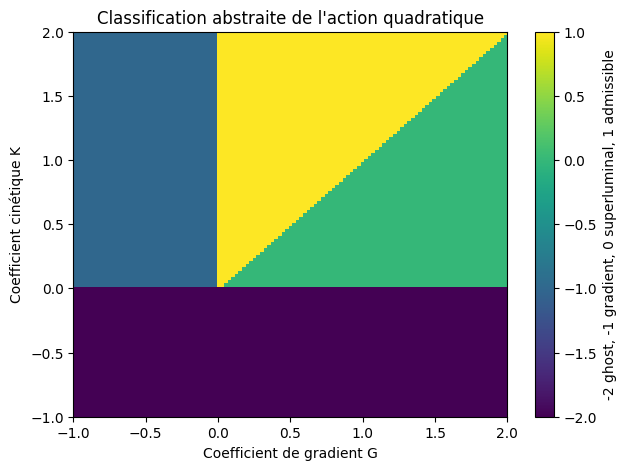

In [13]:

K_values = np.linspace(-1.0, 2.0, 121)
G_values = np.linspace(-1.0, 2.0, 121)

classification_grid = np.empty(
    (len(K_values), len(G_values)),
    dtype=int
)

# -2 ghost, -1 gradient instable, 0 superluminal, 1 admissible
for i, Kv in enumerate(K_values):
    for j, Gv in enumerate(G_values):
        if Kv <= 0:
            classification_grid[i,j] = -2
        else:
            cs2_val = Gv/Kv

            if cs2_val < 0:
                classification_grid[i,j] = -1
            elif cs2_val > 1:
                classification_grid[i,j] = 0
            else:
                classification_grid[i,j] = 1

plt.figure(figsize=(7,5))
plt.imshow(
    classification_grid,
    origin="lower",
    extent=[
        G_values.min(),
        G_values.max(),
        K_values.min(),
        K_values.max()
    ],
    aspect="auto"
)
plt.xlabel("Coefficient de gradient G")
plt.ylabel("Coefficient cinétique K")
plt.title("Classification abstraite de l'action quadratique")
plt.colorbar(label="-2 ghost, -1 gradient, 0 superluminal, 1 admissible")
plt.show()



# 13. Candidat \(f(R)\) minimal

Une extension simple est :

\[
f(R)=R+\alpha R^2.
\]

Conditions usuelles de viabilité locale :

\[
f_R>0,
\qquad
f_{RR}>0,
\]

dans le domaine étudié.

Ici :

\[
f_R=1+2\alpha R,
\qquad
f_{RR}=2\alpha.
\]

Cette action ajoute un degré de liberté scalaire effectif.


In [14]:

R, alpha_R2 = sp.symbols(
    "R alpha_R2",
    real=True
)

f_R_model = R + alpha_R2*R**2
df_dR = sp.diff(f_R_model, R)
d2f_dR2 = sp.diff(f_R_model, R, 2)

print("f(R) =")
display(f_R_model)

print("f_R =")
display(df_dR)

print("f_RR =")
display(d2f_dR2)


f(R) =


 2         
R ⋅α_R2 + R

f_R =


2⋅R⋅α_R2 + 1

f_RR =


2⋅α_R2


# 14. Transformation auxiliaire de \(R+\alpha R^2\)

On introduit un champ auxiliaire \(\chi\) :

\[
S
\sim
\int\sqrt{-g}
\left[
f'(\chi)(R-\chi)
+
f(\chi)
\right].
\]

Pour \(f''(\chi)\neq0\), l'équation de \(\chi\) impose :

\[
\chi=R.
\]

Cette reformulation montre explicitement le degré de liberté scalaire.


In [15]:

chi_aux = sp.symbols("chi_aux", real=True)

f_chi = chi_aux + alpha_R2*chi_aux**2
fp_chi = sp.diff(f_chi, chi_aux)

L_aux_density = sp.expand(
    fp_chi*(R-chi_aux)
    + f_chi
)

EL_chi = sp.simplify(
    sp.diff(L_aux_density, chi_aux)
)

print("Densité auxiliaire :")
display(sp.factor(L_aux_density))

print("Équation du champ auxiliaire :")
display(sp.factor(EL_chi))


Densité auxiliaire :


                             2
2⋅R⋅α_R2⋅χₐᵤₓ + R - α_R2⋅χₐᵤₓ 

Équation du champ auxiliaire :


2⋅α_R2⋅(R - χₐᵤₓ)


# 15. Problème des structures directionnelles fixes

Une action contenant directement un axe fixe, par exemple un vecteur non dynamique \(n^\mu\), peut introduire un repère privilégié :

\[
S
\supset
\int\sqrt{-g}\,
n^\mu n^\nu R_{\mu\nu}.
\]

Pour préserver la covariance, plusieurs options existent :

1. \(n^\mu\) est un champ dynamique ;
2. il est construit à partir d'un scalaire :
   \[
   n_\mu
   \propto
   \nabla_\mu\varphi;
   \]
3. des contraintes imposent sa norme ;
4. la structure directionnelle est tensorielle et transforme correctement.

Une diagonale cubique ne peut pas être simplement fixée dans un repère particulier si elle prétend décrire une physique covariante.


In [16]:

directional_options = pd.DataFrame([
    {
        "structure": "axes fixes externes",
        "covariance": "non",
        "statut": "rejet sans mécanisme"
    },
    {
        "structure": "vecteur dynamique u^mu",
        "covariance": "possible",
        "statut": "analyse des contraintes requise"
    },
    {
        "structure": "gradient d'un scalaire",
        "covariance": "oui",
        "statut": "candidat prudent"
    },
    {
        "structure": "tétrade dynamique",
        "covariance": "oui",
        "statut": "jauge locale à traiter"
    },
    {
        "structure": "tenseur symétrique additionnel",
        "covariance": "oui",
        "statut": "degrés de liberté à compter"
    }
])

directional_options


,structure,covariance,statut
0,axes fixes externes,non,rejet sans mécanisme
1,vecteur dynamique u^mu,possible,analyse des contraintes requise
2,gradient d'un scalaire,oui,candidat prudent
3,tétrade dynamique,oui,jauge locale à traiter
4,tenseur symétrique additionnel,oui,degrés de liberté à compter



# 16. Proposition minimale de travail GVH

Une action exploratoire prudente pourrait être écrite :

\[
S_{\mathrm{GVH,trial}}
=
\int d^4x\sqrt{-g}
\left[
\frac{M_{\mathrm{Pl}}^2}{2}F(\varphi)R
-\frac12Z(\varphi)(\nabla\varphi)^2
-V(\varphi)
+\epsilon\,\mathcal I_{\mathrm{GVH}}
\right]
+
S_m.
\]

Le terme \(\mathcal I_{\mathrm{GVH}}\) doit être :

- scalaire covariant ;
- local, sauf justification contraire ;
- dimensionnellement cohérent ;
- compatible avec la limite d'Einstein ;
- dégénéré si des dérivées supérieures apparaissent ;
- falsifiable.

Dans cette version, nous ne choisissons pas encore \(\mathcal I_{\mathrm{GVH}}\).



# 17. Critères de sélection d'une action candidate

Une action candidate doit passer les tests suivants :

1. **Covariance**
   \[
   S \text{ scalaire sous difféomorphismes}.
   \]

2. **Limite d'Einstein**
   \[
   \epsilon\to0
   \Rightarrow
   S\to S_{\mathrm{EH}}.
   \]

3. **Comptage des degrés de liberté**

4. **Contraintes primaires et secondaires**

5. **Action quadratique**

6. **Absence de ghosts**
   \[
   K_i>0.
   \]

7. **Stabilité de gradient**
   \[
   c_{s,i}^2\ge0.
   \]

8. **Causalité ou cône effectif contrôlé**

9. **Vide de référence stable**

10. **Compatibilité observationnelle**

11. **Prédiction nouvelle non obtenue par simple changement de coordonnées**


In [17]:

selection_criteria = pd.DataFrame([
    {"test": "Covariance", "critical": True},
    {"test": "Limite Einstein", "critical": True},
    {"test": "Dimensions", "critical": True},
    {"test": "DOF identifiés", "critical": True},
    {"test": "Contraintes analysées", "critical": True},
    {"test": "Action quadratique", "critical": True},
    {"test": "Absence de ghosts", "critical": True},
    {"test": "Stabilité gradient", "critical": True},
    {"test": "Vide stable", "critical": True},
    {"test": "Compatibilité faible", "critical": True},
    {"test": "Prédiction falsifiable", "critical": False}
])

selection_criteria


,test,critical
0,Covariance,True
1,Limite Einstein,True
2,Dimensions,True
3,DOF identifiés,True
4,Contraintes analysées,True
5,Action quadratique,True
6,Absence de ghosts,True
7,Stabilité gradient,True
8,Vide stable,True
9,Compatibilité faible,True



# 18. Audit de plusieurs candidats

Nous construisons un audit qualitatif initial.

Les résultats ne remplacent pas une dérivation complète.


In [18]:

action_audit = pd.DataFrame([
    {
        "candidate": "Einstein-Hilbert",
        "covariant": True,
        "einstein_limit": True,
        "second_order_or_degenerate": True,
        "dof_known": True,
        "ghost_status": "healthy reference",
        "new_GVH_content": False
    },
    {
        "candidate": "Scalar-tensor minimal",
        "covariant": True,
        "einstein_limit": True,
        "second_order_or_degenerate": True,
        "dof_known": True,
        "ghost_status": "depends on F and Z",
        "new_GVH_content": "possible"
    },
    {
        "candidate": "R + alpha R^2",
        "covariant": True,
        "einstein_limit": True,
        "second_order_or_degenerate": "scalar reformulation",
        "dof_known": True,
        "ghost_status": "test f_R and f_RR",
        "new_GVH_content": "not specifically GVH"
    },
    {
        "candidate": "R + beta Ricci^2 generic",
        "covariant": True,
        "einstein_limit": True,
        "second_order_or_degenerate": False,
        "dof_known": "extra modes",
        "ghost_status": "high-risk",
        "new_GVH_content": "not specifically GVH"
    },
    {
        "candidate": "Fixed cubic axes",
        "covariant": False,
        "einstein_limit": "unclear",
        "second_order_or_degenerate": "unclear",
        "dof_known": False,
        "ghost_status": "unknown",
        "new_GVH_content": "invalid as written"
    }
])

action_audit


,candidate,covariant,einstein_limit,second_order_or_degenerate,dof_known,ghost_status,new_GVH_content
0,Einstein-Hilbert,True,True,True,True,healthy reference,False
1,Scalar-tensor minimal,True,True,True,True,depends on F and Z,possible
2,R + alpha R^2,True,True,scalar reformulation,True,test f_R and f_RR,not specifically GVH
3,R + beta Ricci^2 generic,True,True,False,extra modes,high-risk,not specifically GVH
4,Fixed cubic axes,False,unclear,unclear,False,unknown,invalid as written



# 19. Validation automatisée de l'infrastructure

Cette validation vérifie :

- Euler–Lagrange de l'oscillateur ;
- apparition d'un ordre quatre avec \(\ddot q^2\) ;
- limite d'Einstein du candidat scalaire–tenseur ;
- dégénérescence du lapse dans le modèle réduit ;
- équation auxiliaire de \(R+\alpha R^2\).


In [19]:

oscillator_expected = sp.simplify(
    m*(sp.diff(q,t,2)+omega**2*q)
)

oscillator_ok = (
    sp.simplify(EL_osc-oscillator_expected) == 0
)

higher_derivative_present = (
    EL_hd.has(sp.diff(q_hd,t,4))
)

einstein_limit_ok = (
    einstein_limit["F_limit"] == 1
    and einstein_limit["Z_limit"] == 1
    and einstein_limit["V_limit"] == 0
)

lapse_degenerate = (
    sp.simplify(K_mini.det()) == 0
)

auxiliary_ok = (
    sp.factor(EL_chi)
    == sp.factor(2*alpha_R2*(R-chi_aux))
)

validation_rows = [
    {
        "test": "Euler-Lagrange oscillateur",
        "status": "PASS" if oscillator_ok else "FAIL"
    },
    {
        "test": "Ordre supérieur détecté",
        "status": (
            "PASS"
            if higher_derivative_present
            else "FAIL"
        )
    },
    {
        "test": "Limite Einstein",
        "status": (
            "PASS"
            if einstein_limit_ok
            else "FAIL"
        )
    },
    {
        "test": "Contrainte lapse",
        "status": (
            "PASS"
            if lapse_degenerate
            else "FAIL"
        )
    },
    {
        "test": "Champ auxiliaire R²",
        "status": (
            "PASS"
            if auxiliary_ok
            else "CHECK"
        )
    }
]

validation_df = pd.DataFrame(validation_rows)
validation_df


,test,status
0,Euler-Lagrange oscillateur,PASS
1,Ordre supérieur détecté,PASS
2,Limite Einstein,PASS
3,Contrainte lapse,PASS
4,Champ auxiliaire R²,PASS


In [20]:

overall_status = (
    "PASS"
    if (validation_df["status"] == "PASS").all()
    else "CHECK"
)

print("STATUT DU NOTEBOOK :", overall_status)


STATUT DU NOTEBOOK : PASS



# 20. Export des résultats


In [21]:

import json
from pathlib import Path

audit_path = Path(
    "GVH_Diagonal_Cubic_0.2.10_Action_Audit.csv"
)

criteria_path = Path(
    "GVH_Diagonal_Cubic_0.2.10_Selection_Criteria.csv"
)

validation_path = Path(
    "GVH_Diagonal_Cubic_0.2.10_Validation.csv"
)

metadata_path = Path(
    "GVH_Diagonal_Cubic_0.2.10_Metadata.json"
)

action_audit.to_csv(audit_path, index=False)
selection_criteria.to_csv(
    criteria_path,
    index=False
)
validation_df.to_csv(
    validation_path,
    index=False
)

metadata = {
    "notebook_status": overall_status,
    "preferred_trial_family": (
        "covariant scalar-tensor with Einstein limit"
    ),
    "fundamental_GVH_invariant": (
        "not yet defined"
    ),
    "ghost_proof_status": (
        "not available until quadratic action is derived"
    )
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Exports terminés :")
print(audit_path)
print(criteria_path)
print(validation_path)
print(metadata_path)


Exports terminés :
GVH_Diagonal_Cubic_0.2.10_Action_Audit.csv
GVH_Diagonal_Cubic_0.2.10_Selection_Criteria.csv
GVH_Diagonal_Cubic_0.2.10_Validation.csv
GVH_Diagonal_Cubic_0.2.10_Metadata.json



# 21. Décision scientifique de la version 0.2.10

La version actuelle ne permet pas encore d'affirmer :

\[
S_{\mathrm{GVH}}
=
\text{action fondamentale validée}.
\]

Elle permet cependant de conclure que :

1. une action reposant sur des axes cubiques fixes serait insuffisamment covariante ;
2. une extension scalaire–tenseur covariante constitue un point de départ plus prudent ;
3. une correction avec dérivées supérieures doit être dégénérée ou reformulée ;
4. l'absence de ghost ne peut être décidée à partir de la métrique seule ;
5. la prochaine étape doit définir l'invariant covariant propre à GVH.

---

## Problème ouvert central

Il faut construire un scalaire :

\[
\mathcal I_{\mathrm{GVH}}
=
\mathcal I_{\mathrm{GVH}}
(
g_{\mu\nu},
\varphi,
\nabla\varphi,
R_{\mu\nu\rho\sigma},
\ldots
),
\]

qui représente réellement l'idée diagonale ou directionnelle de GVH sans sélectionner arbitrairement les axes \(x,y,z\).



# 22. Conclusion et prochaine étape

Cette version introduit la chaîne variationnelle :

\[
S
\longrightarrow
\delta S
\longrightarrow
\text{équations de champ}
\longrightarrow
\text{contraintes}
\longrightarrow
S^{(2)}
\longrightarrow
\text{ghosts et stabilité}.
\]

Elle fournit :

1. action d'Einstein–Hilbert de référence ;
2. moteur Euler–Lagrange ;
3. hessienne cinétique ;
4. exemple d'Ostrogradski ;
5. classification des familles d'actions ;
6. candidat scalaire–tenseur minimal ;
7. limite d'Einstein ;
8. modèle réduit avec lapse ;
9. contrainte hamiltonienne ;
10. action quadratique schématique ;
11. banc de causalité et de ghosts ;
12. reformulation auxiliaire de \(R+\alpha R^2\) ;
13. audit des structures directionnelles ;
14. critères de sélection ;
15. exports reproductibles.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.11\_Covariant\_GVH\_Invariant.ipynb}
}
\]

Elle devra construire et comparer plusieurs invariants candidats :

- scalaire construit à partir d'un champ \(\varphi\) ;
- décomposition par projecteur spatial ;
- tenseur directionnel dynamique ;
- invariants de cisaillement, expansion et courbure ;
- limite isotrope ;
- covariance sous rotation et boost ;
- dimensions et symétries ;
- compatibilité avec l'action 0.2.10.
